In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.metrics import classification_report
import zipfile
import random

In [2]:
zip_path = "/content/drive/MyDrive/Datasets/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

train_dir = "/content/FruitinAmazon/FruitinAmazon/train"

In [3]:
img_height = 128
img_width = 128
batch_size = 8

rescale = tf.keras.layers.Rescaling(1./255)

seed = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3)
])

In [5]:
model = models.Sequential([
    layers.Input(shape=(128,128,3)),

    data_augmentation,

    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.2083 - loss: 2.6304 - val_accuracy: 0.2222 - val_loss: 1.8483
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.2361 - loss: 1.6615 - val_accuracy: 0.2222 - val_loss: 1.7069
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.3333 - loss: 1.5228 - val_accuracy: 0.2222 - val_loss: 1.7969
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.3472 - loss: 1.5184 - val_accuracy: 0.2778 - val_loss: 1.6604
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 260ms/step - accuracy: 0.3611 - loss: 1.4688 - val_accuracy: 0.2778 - val_loss: 1.6056
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step - accuracy: 0.4583 - loss: 1.3128 - val_accuracy: 0.3889 - val_loss: 1.8677
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step - accuracy: 0.3333 - loss: 1.3204 - val_accuracy: 0.2778 - val_loss: 1.6504
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.4444 - loss: 1.2937 - val_accuracy: 0.3333 - val_loss:

In [8]:
loss, acc = model.evaluate(val_ds)
print("CNN Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6111 - loss: 1.1530
CNN Accuracy: 0.6111111044883728


In [9]:
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = np.argmax(model.predict(val_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.00      0.00      0.00         3
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.33      0.33      0.33         3

    accuracy                           0.06        18
   macro avg       0.06      0.06      0.06        18
weighted avg       0.06      0.06      0.06        18



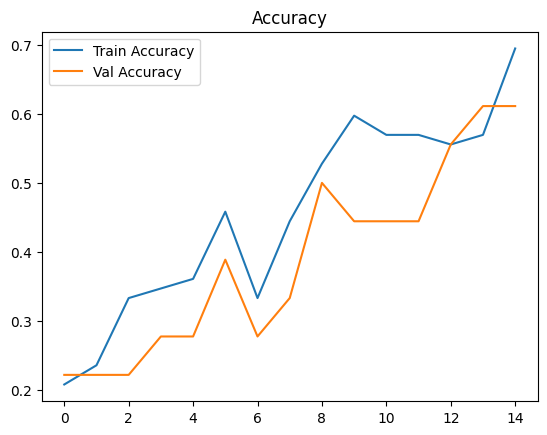

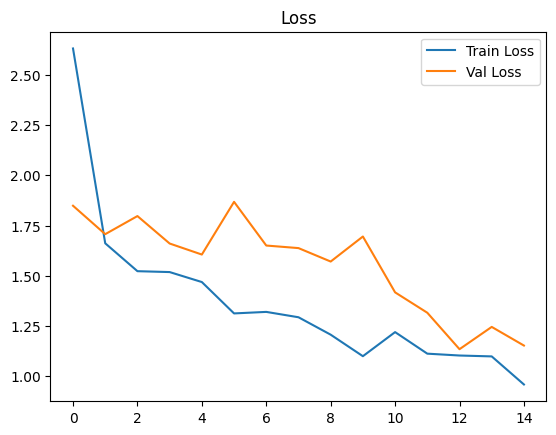

In [10]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [11]:
from keras.applications.vgg16 import preprocess_input

def vgg_preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

train_ds_vgg = train_ds.map(vgg_preprocess)
val_ds_vgg = val_ds.map(vgg_preprocess)

In [12]:
from keras.applications import VGG16
from keras import layers, models
from keras.models import Model

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=output)

In [14]:
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history_vgg = vgg_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=5
)

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.1944 - loss: 2.9913 - val_accuracy: 0.1667 - val_loss: 3.0005
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.1944 - loss: 2.9686 - val_accuracy: 0.1667 - val_loss: 2.9901
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.1944 - loss: 3.0479 - val_accuracy: 0.2222 - val_loss: 2.9792
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.2083 - loss: 2.9725 - val_accuracy: 0.2222 - val_loss: 2.9689
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.2222 - loss: 2.8297 - val_accuracy: 0.2222 - val_loss: 2.9584


In [16]:
loss, acc = vgg_model.evaluate(val_ds_vgg)
print("VGG Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 839ms/step - accuracy: 0.2222 - loss: 2.9584
VGG Accuracy: 0.2222222238779068


In [17]:
y_true = np.concatenate([y for x, y in val_ds_vgg], axis=0)

y_pred_probs = vgg_model.predict(val_ds_vgg)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 883ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.33      0.67      0.44         3
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.17      0.67      0.27         3

    accuracy                           0.22        18
   macro avg       0.08      0.22      0.12        18
weighted avg       0.08      0.22      0.12        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


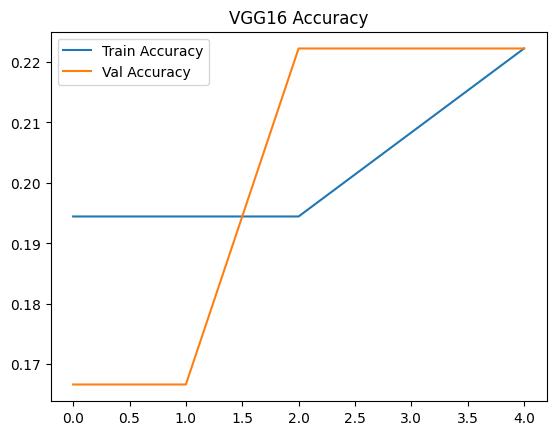

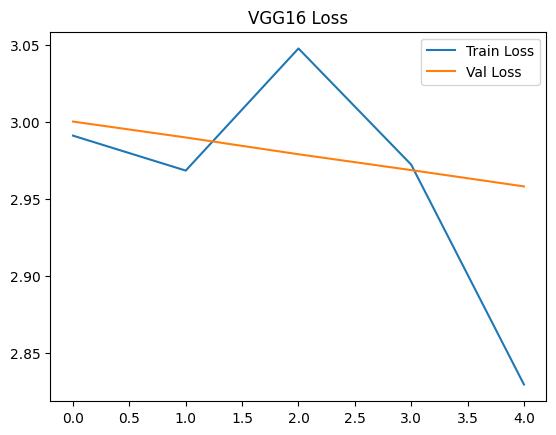

In [18]:
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("VGG16 Accuracy")
plt.show()

plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("VGG16 Loss")
plt.show()